In [4]:
from ast import unaryop
import numpy as np
import pandas as pd
# set random seed for reproducibility
np.random.seed(42)
#define number of samples
num_samples=100
#generate synthetic data
carbon_emissions=np.random.uniform(50,400,num_samples)
energy_output=np.random.uniform(100,1000,num_samples)
renewability_index=np.random.uniform(0,1,num_samples)
cost_efficiency=np.random.uniform(0.5,5,num_samples)

#generating a binary target variable based on a condition
# this is just an example :high renewability and low emissions favor sustainability
sustainability = [
    1 if (emission < 200 and renewability > 0.5 and cost < 3) else 0
    for emission, renewability, cost in zip(carbon_emissions, renewability_index, cost_efficiency)
]

#create DataFrame
data=pd.DataFrame({
    'carbon_emissions':carbon_emissions,
    'energy_output':energy_output,
    'renewability_index':renewability_index,
    'cost_efficiency':cost_efficiency,
    'sustainability':sustainability
})

#display the first few rows
print(data.head())
#optionally,save to CSV for later use
data.to_csv('green_tech_data.csv',index=False)





   carbon_emissions  energy_output  renewability_index  cost_efficiency  \
0        181.089042     128.286267            0.642032         0.732568   
1        382.750007     672.769370            0.084140         2.891096   
2        306.197880     382.920383            0.161629         2.932858   
3        259.530469     557.713622            0.898554         3.368435   
4        104.606524     916.809827            0.606429         3.767411   

   sustainability  
0               1  
1               0  
2               0  
3               0  
4               0  


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
#load the dataset
data=pd.read_csv('green_tech_data.csv')
#inspect for missing values and general structure
print(data.head())
print(data.isnull().sum())
#handles missing vales if necessary
data.fillna(data.mean(),inplace=True)


   carbon_emissions  energy_output  renewability_index  cost_efficiency  \
0        181.089042     128.286267            0.642032         0.732568   
1        382.750007     672.769370            0.084140         2.891096   
2        306.197880     382.920383            0.161629         2.932858   
3        259.530469     557.713622            0.898554         3.368435   
4        104.606524     916.809827            0.606429         3.767411   

   sustainability  
0               1  
1               0  
2               0  
3               0  
4               0  
carbon_emissions      0
energy_output         0
renewability_index    0
cost_efficiency       0
sustainability        0
dtype: int64


In [8]:
X=data[['carbon_emissions','energy_output','renewability_index','cost_efficiency']]
y=data['sustainability']

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [11]:
y_pred=model.predict(X_test)

In [12]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [13]:
#Accuracy Score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


Accuracy: 0.95


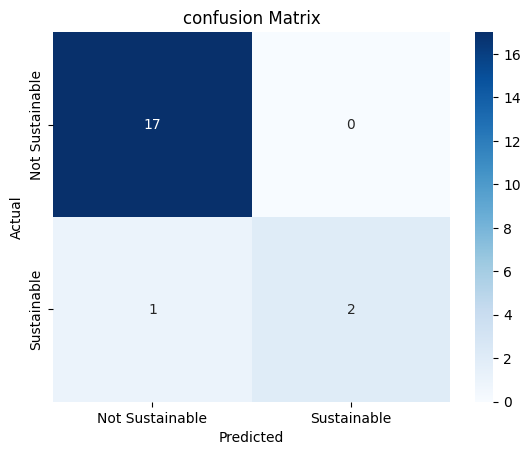

In [17]:
#Confusion Matrix
conf_matrix=confusion_matrix(y_test,y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sustainable', 'Sustainable'],
            yticklabels=['Not Sustainable', 'Sustainable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('confusion Matrix')
plt.show()

In [18]:
#features importance
coefficients=pd.DataFrame(model.coef_.T,index=X.columns,columns=['coeffficient'])
print(coefficients)

                    coeffficient
carbon_emissions       -0.023347
energy_output           0.001097
renewability_index      1.092184
cost_efficiency        -1.259560


In [20]:
import joblib
#save the model to a file
joblib.dump(model,'lrmodel_sustainable.pkl')


['lrmodel_sustainable.pkl']